# Week 11 Tutorial - Convolutional Neural Networks

**How to use this notebook:**
Read one section of `study-guide.md`, then do that section here before moving on.

Each section has:
- A worked example (pre-written - just run it)
- A **DO IT YOURSELF** cell with a follow-up task

---

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

PyTorch version: 2.8.0+cu126
Device: cuda


---
## Section 1 — Why MLPs Fail on Images
### EXAMPLE

In [2]:
# EXAMPLE: compare parameter counts — MLP vs CNN on image data

# MLP on 28x28 grayscale image
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 512),   # 784 inputs -> 512 neurons
    nn.ReLU(),
    nn.Linear(512, 10)
)

mlp_params = sum(p.numel() for p in mlp.parameters())
print(f'MLP parameters: {mlp_params:,}')

# CNN on 28x28 grayscale image
cnn = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(32, 64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(64*5*5, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

cnn_params = sum(p.numel() for p in cnn.parameters())
print(f'CNN parameters: {cnn_params:,}')
print(f'MLP uses {mlp_params / cnn_params:.1f}x more parameters than CNN')

MLP parameters: 407,050
CNN parameters: 225,034
MLP uses 1.8x more parameters than CNN


### DO IT YOURSELF - Section 1

1. Calculate (by hand or in code) how many parameters a single `nn.Linear(784, 512)` layer has — include both weights and bias
2. Now calculate how many parameters a `nn.Conv2d(1, 32, kernel_size=3)` layer has — a 3×3 filter has 9 weights, plus 1 bias per filter
3. Print both and comment: why does the Conv layer use so many fewer parameters?

In [3]:
# DO IT YOURSELF - Section 1
# YOUR CODE HERE
# nn.Linear(784, 512) has 401408 parameters + 512
# nn.Conv2d(1, 64, kernel_size=3) has 640 parameters

print(f'nn.Linear(784, 512) has 401920 parameters')
print(f'nn.Conv2d(1, 64, kernel_size=3) has 640 parameters')
# Conv layer does not require so many parameters because instead of connecting to each neurons by pixel it uses filters that slides cross the image
# meaning that if kernel_size is 3 than each neuron only needs 9 inputs

nn.Linear(784, 512) has 401920 parameters
nn.Conv2d(1, 64, kernel_size=3) has 640 parameters


---
## Section 2 — The Convolution Operation
### EXAMPLE

In [4]:
# EXAMPLE: manual convolution to show what it computes
# A filter slides over the image, computing a dot product at each position

import torch.nn.functional as F

# 5x5 image (1 batch, 1 channel)
image = torch.tensor([[[
    [1., 2., 3., 0., 1.],
    [0., 1., 2., 1., 0.],
    [1., 0., 1., 0., 1.],
    [0., 1., 0., 1., 0.],
    [1., 0., 1., 0., 1.]
]]])

# vertical edge detector filter (3x3)
# detects left-to-right intensity changes
v_filter = torch.tensor([[[[ 1., 0., -1.],
                             [ 1., 0., -1.],
                             [ 1., 0., -1.]]]])

# apply convolution manually
output = F.conv2d(image, v_filter)

print('Input image (5x5):')
print(image[0, 0])
print()
print('Filter (3x3 vertical edge detector):')
print(v_filter[0, 0])
print()
print('Output feature map (3x3):')
print(output[0, 0])
print()
print(f'Input shape:  {image.shape}   (batch=1, channels=1, 5x5)')
print(f'Output shape: {output.shape}  (batch=1, channels=1, 3x3)')
print(f'Size went from 5 to {output.shape[-1]}: (5 - 3) / 1 + 1 = 3')

Input image (5x5):
tensor([[1., 2., 3., 0., 1.],
        [0., 1., 2., 1., 0.],
        [1., 0., 1., 0., 1.],
        [0., 1., 0., 1., 0.],
        [1., 0., 1., 0., 1.]])

Filter (3x3 vertical edge detector):
tensor([[ 1.,  0., -1.],
        [ 1.,  0., -1.],
        [ 1.,  0., -1.]])

Output feature map (3x3):
tensor([[-4.,  2.,  4.],
        [-2.,  0.,  2.],
        [ 0.,  0.,  0.]])

Input shape:  torch.Size([1, 1, 5, 5])   (batch=1, channels=1, 5x5)
Output shape: torch.Size([1, 1, 3, 3])  (batch=1, channels=1, 3x3)
Size went from 5 to 3: (5 - 3) / 1 + 1 = 3


Image shape: torch.Size([1, 28, 28])   label: 5


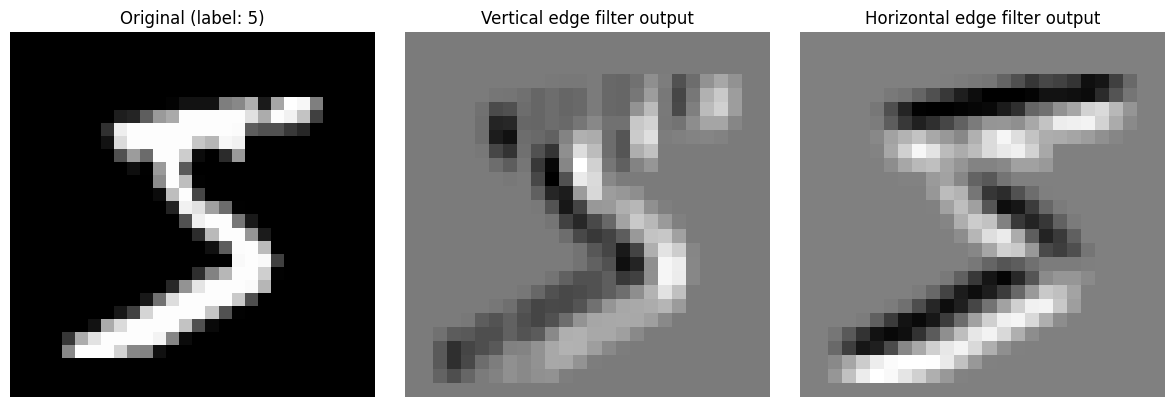

In [7]:
# EXAMPLE: visualize what a real CNN filter detects on an actual MNIST image

# load one MNIST image
mnist = datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor())
img, label = mnist[0]
print(f'Image shape: {img.shape}   label: {label}')

# add batch dimension: (1, 28, 28) → (1, 1, 28, 28)
img_batch = img.unsqueeze(0)

# apply vertical edge filter
v_filter = torch.tensor([[[[ 1., 0., -1.],
                             [ 1., 0., -1.],
                             [ 1., 0., -1.]]]])
h_filter = torch.tensor([[[[ 1.,  1.,  1.],
                             [ 0.,  0.,  0.],
                             [-1., -1., -1.]]]])

v_out = F.conv2d(img_batch, v_filter)
h_out = F.conv2d(img_batch, h_filter)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img[0], cmap='gray')
axes[0].set_title(f'Original (label: {label})')
axes[1].imshow(v_out[0, 0].detach(), cmap='gray')
axes[1].set_title('Vertical edge filter output')
axes[2].imshow(h_out[0, 0].detach(), cmap='gray')
axes[2].set_title('Horizontal edge filter output')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

### DO IT YOURSELF - Section 2

1. Take the same MNIST image from the example above
2. Create a diagonal edge filter: a 3×3 filter with `1` on the top-left to bottom-right diagonal and `0` elsewhere
3. Apply it and plot the original image alongside the filter output
4. Comment: what does the output highlight compared to the vertical and horizontal filters?

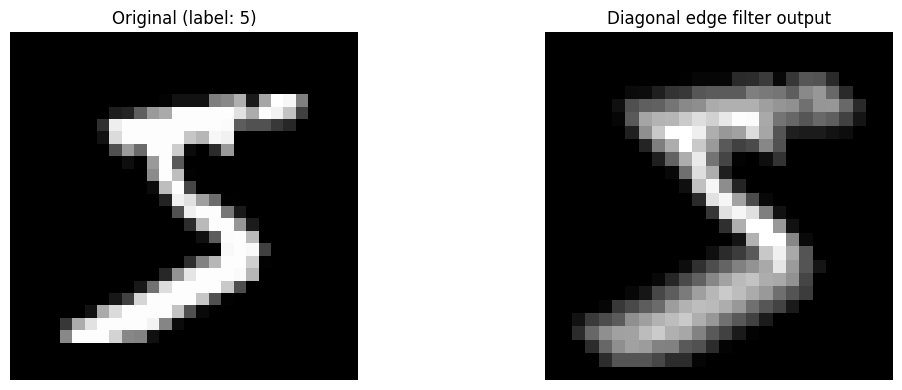

In [20]:
# DO IT YOURSELF - Section 2
# YOUR CODE HERE

d_filter = torch.tensor([[[[ 1.,  0.,  0.],
                             [ 0.,  1.,  0.],
                             [0., 0., 1.]]]])

d_out = F.conv2d(img_batch, d_filter)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img[0], cmap='gray')
axes[0].set_title(f'Original (label: {label})')
axes[1].imshow(d_out[0, 0].detach(), cmap='gray')
axes[1].set_title('Diagonal edge filter output')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# 5 that makes diagonal line from left ro right is highlighted slightly

---
## Section 3 — nn.Conv2d and Shape Tracking
### EXAMPLE

In [21]:
# EXAMPLE: track shapes through each layer of a CNN
# This is the most important debugging skill for CNNs

# dummy input: batch of 4 grayscale 28x28 images
x = torch.randn(4, 1, 28, 28)   # (batch, channels, height, width)
print(f'Input:          {tuple(x.shape)}')

conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
x = conv1(x)
print(f'After Conv2d(1,32,3):  {tuple(x.shape)}   # (5-3)/1+1=26 per side')

x = torch.relu(x)
print(f'After ReLU:     {tuple(x.shape)}   # shape unchanged')

pool = nn.MaxPool2d(kernel_size=2, stride=2)
x = pool(x)
print(f'After MaxPool2d(2,2):  {tuple(x.shape)}   # 26//2=13 per side')

conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
x = conv2(x)
print(f'After Conv2d(32,64,3): {tuple(x.shape)}   # 13-3+1=11 per side')

x = torch.relu(x)
pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
x = pool2(x)
print(f'After MaxPool2d(2,2):  {tuple(x.shape)}   # 11//2=5 per side')

flatten = nn.Flatten()
x = flatten(x)
print(f'After Flatten:  {tuple(x.shape)}   # 64*5*5=1600')

fc = nn.Linear(1600, 10)
x = fc(x)
print(f'After Linear:   {tuple(x.shape)}   # 10 classes')

Input:          (4, 1, 28, 28)
After Conv2d(1,32,3):  (4, 32, 26, 26)   # (5-3)/1+1=26 per side
After ReLU:     (4, 32, 26, 26)   # shape unchanged
After MaxPool2d(2,2):  (4, 32, 13, 13)   # 26//2=13 per side
After Conv2d(32,64,3): (4, 64, 11, 11)   # 13-3+1=11 per side
After MaxPool2d(2,2):  (4, 64, 5, 5)   # 11//2=5 per side
After Flatten:  (4, 1600)   # 64*5*5=1600
After Linear:   (4, 10)   # 10 classes


### DO IT YOURSELF - Section 3

Track shapes through this architecture **before running it**. Write your expected shape after each layer as a comment, then run to verify.

Architecture: input (1, 32, 32) → Conv2d(1, 16, 5) → MaxPool2d(2,2) → Conv2d(16, 32, 3) → MaxPool2d(2,2) → Flatten → Linear(?, 10)

1. Work out the shape after each layer manually using the formula from the study guide
2. Fill in the `?` for the Linear layer input size
3. Write the code and run it to verify your shapes were correct

In [29]:
# DO IT YOURSELF - Section 3
# YOUR CODE HERE
# Hint: input is (batch, 1, 32, 32) — note this is 32x32, not 28x28

x = torch.randn(4, 1, 32, 32)
print(f'Input: {tuple(x.shape)}')

# After Conv2d(1, 16, 3):    expected shape: (4, 16, 30, 30)
conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
x = conv1(x)
print(f'After Conv2d(1,16,3):  {tuple(x.shape)}')
      
# After MaxPool2d(2, 2):     expected shape: (4, 16, 15, 15)
pool = nn.MaxPool2d(kernel_size=2, stride=2)
x = pool(x)
print(f'After MaxPool2d(2, 2):  {tuple(x.shape)}')

# After Conv2d(16, 32, 3):   expected shape: (4, 32, 13, 13)
conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
x = conv2(x)
print(f'After Conv2d(16,32,3):  {tuple(x.shape)}')

# After MaxPool2d(2, 2):     expected shape: (4, 32, 6, 6)
pool = nn.MaxPool2d(kernel_size=2, stride=2)
x = pool(x)
print(f'After MaxPool2d(2, 2):  {tuple(x.shape)}')

# After Flatten:             expected shape: (4, 1152)
flatten = nn.Flatten()
x = flatten(x)
print(f'After Flatten:  {tuple(x.shape)}')

# Linear input size = 1152
fc = nn.Linear(1152, 10)
x = fc(x)
print(f'After Linear:   {tuple(x.shape)}   # 10 classes')


Input: (4, 1, 32, 32)
After Conv2d(1,16,3):  (4, 16, 30, 30)
After MaxPool2d(2, 2):  (4, 16, 15, 15)
After Conv2d(16,32,3):  (4, 32, 13, 13)
After MaxPool2d(2, 2):  (4, 32, 6, 6)
After Flatten:  (4, 1152)
After Linear:   (4, 10)   # 10 classes


---
## Section 4 — Full CNN on MNIST
### EXAMPLE

In [31]:
# EXAMPLE: load MNIST and train a CNN
# Training loop is identical to week 10 — only the model changes

torch.manual_seed(42)

# transforms.ToTensor() converts PIL image to float32 tensor and scales pixels to [0, 1]
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# DataLoader — same as week 10
# y dtype is already torch.long (integers 0-9) — CrossEntropyLoss requires integers, not floats
# y shape is already (batch,) — no unsqueeze needed (unlike BCEWithLogitsLoss which needed (batch,1))
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f'Training samples: {len(train_data)}')
print(f'Test samples:     {len(test_data)}')

# peek at one batch
X_batch, y_batch = next(iter(train_loader))
print(f'Batch X shape: {X_batch.shape}   (batch, channels, height, width)')
print(f'Batch y shape: {y_batch.shape}   (batch,) — class indices 0-9')
print(f'y dtype: {y_batch.dtype}   (torch.long — required by CrossEntropyLoss)')

Training samples: 60000
Test samples:     10000
Batch X shape: torch.Size([64, 1, 28, 28])   (batch, channels, height, width)
Batch y shape: torch.Size([64])   (batch,) — class indices 0-9
y dtype: torch.int64   (torch.long — required by CrossEntropyLoss)


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)
Total parameters: 225,034
Epoch 1: train loss=0.1844  val loss=0.0481
Epoch 2: train loss=0.0505  val loss=0.0309
Epoch 3: train loss=0.0363  val loss=0.0294
Epoch 4: train loss=0.0268  val loss=0.0389
Epoch 5: train loss=0.0206  val loss=0.0283


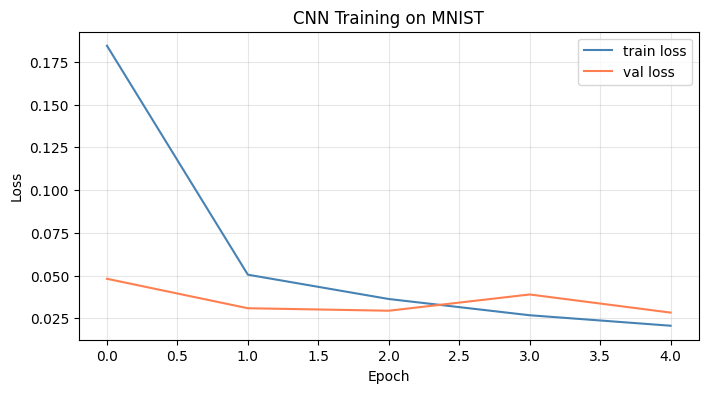

In [32]:
# EXAMPLE: define and train the CNN

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)   # (1,28,28) → (32,26,26)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)  # (32,13,13) → (64,11,11)
        self.pool  = nn.MaxPool2d(2, 2)                # halves spatial dims
        self.fc1   = nn.Linear(64*5*5, 128)
        self.fc2   = nn.Linear(128, 10)                # 10 classes, no softmax
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # conv → relu → pool
        x = self.pool(self.relu(self.conv2(x)))   # conv → relu → pool
        x = torch.flatten(x, 1)                   # flatten all dims except batch
        x = self.relu(self.fc1(x))
        x = self.fc2(x)                           # raw logits
        return x

model = CNN().to(device)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

# CrossEntropyLoss for 10 classes — same as multiclass in week 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses   = []

for epoch in range(5):   # 5 epochs is enough for MNIST
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move to GPU
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            batch_val.append(criterion(pred, y_batch).item())
    val_losses.append(np.mean(batch_val))

    print(f'Epoch {epoch+1}: train loss={train_losses[-1]:.4f}  val loss={val_losses[-1]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'steelblue', label='train loss')
plt.plot(val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training on MNIST')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
# EXAMPLE: evaluate accuracy on test set

model.eval()
correct = 0
total   = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        preds  = torch.argmax(logits, dim=1)   # class with highest score
        correct += (preds == y_batch).sum().item()
        total   += y_batch.size(0)

print(f'Test accuracy: {correct/total:.4f} ({correct}/{total})')

Test accuracy: 0.9907 (9907/10000)


### DO IT YOURSELF - Section 4

1. Visualize 9 MNIST test images in a 3×3 grid using `plt.subplot`
2. Under each image show the true label and the model's predicted label
3. Color the title green if correct, red if wrong
4. Comment: what kinds of digits does the model get wrong?

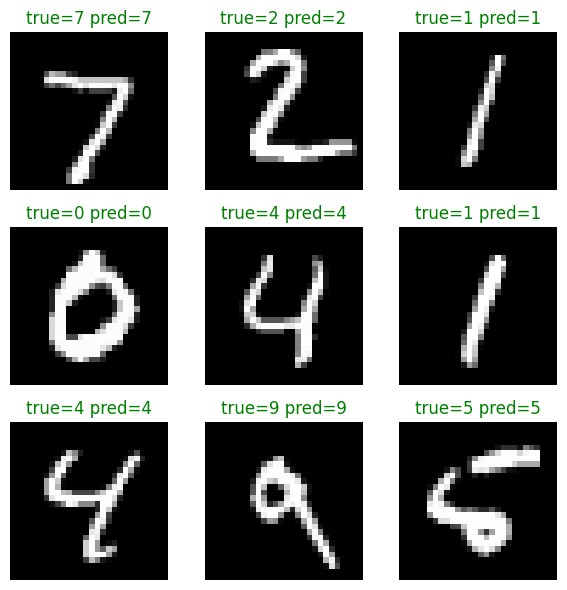

In [ ]:
# DO IT YOURSELF - Section 4
# YOUR CODE HERE
# Hint: get a batch from test_loader, run model, compare preds vs labels
X_batch, y_batch = next(iter(test_loader))   # get one batch of 64 images
X_batch, y_batch = X_batch.to(device), y_batch.to(device)

# run model on the batch
model.eval()
with torch.no_grad():
    logits = model(X_batch)
    preds = torch.argmax(logits, dim=1)

# plot first 9
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_batch[i, 0].cpu(), cmap='gray')
    true  = y_batch[i].item()
    pred  = preds[i].item()
    color = 'green' if true == pred else 'red'
    ax.set_title(f'true={true} pred={pred}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

# based on first 9 it seem like its predicting all images correctly

---
## CAPSTONE — EMNIST Letters

EMNIST is the letter version of MNIST — same 28×28 grayscale format, but 26 classes (a-z) instead of 10 digits.

Your job is to apply everything from this week to a new problem without being guided step by step.

1. Load EMNIST letters using `datasets.EMNIST(root='data', split='letters', train=True, download=True, transform=transform)`
2. Check the label range — EMNIST letters uses 1-26 instead of 0-25. Subtract 1 from all labels to make them 0-25 before passing to CrossEntropyLoss
3. Design your own CNN architecture — choose your own number of layers, filter counts, and kernel sizes
4. Track shapes on paper first before writing the model
5. Train for 5 epochs, plot train + val loss
6. Report test accuracy
7. Written answer: how does accuracy compare to MNIST digit classification? Why might letters be harder?

In [42]:
# CAPSTONE
# YOUR CODE HERE
torch.manual_seed(42)

# transforms.ToTensor() converts PIL image to float32 tensor and scales pixels to [0, 1]
transform = transforms.ToTensor()

train_data = datasets.EMNIST(root='data',split='letters', train=True, download=True, transform=transform)
test_data  = datasets.EMNIST(root='data',split='letters', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)


print(f'Training samples: {len(train_data)}')
print(f'Test samples:     {len(test_data)}')

# peek at one batch
X_batch, y_batch = next(iter(train_loader))
print(f'Batch X shape: {X_batch.shape}   (batch, channels, height, width)')
print(f'Batch y shape: {y_batch.shape}   (batch,) — class indices 0-9')
print(f'y dtype: {y_batch.dtype}   (torch.long/torch.int64 — required by CrossEntropyLoss)')


Training samples: 124800
Test samples:     20800
Batch X shape: torch.Size([64, 1, 28, 28])   (batch, channels, height, width)
Batch y shape: torch.Size([64])   (batch,) — class indices 0-9
y dtype: torch.int64   (torch.long/torch.int64 — required by CrossEntropyLoss)


In [53]:
class AlphaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)  
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128*3*3, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, 26)     
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # conv → relu → pool (32, 26, 26) -> (32, 13, 13)
        x = self.pool(self.relu(self.conv2(x)))   # conv → relu → pool (64, 11, 11) -> (64, 5, 5)
        x = self.relu(self.conv3(x))              # conv → relu → pool (128, 3, 3) 
        x = torch.flatten(x, 1)                   # flatten all dims except batch
        x = self.relu(self.fc1(x))
        x = self.fc2(x)        
        x = self.fc3(x)                   # raw logits
        return x

model = AlphaCNN().to(device)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

AlphaCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=26, bias=True)
  (relu): ReLU()
)
Total parameters: 250,202


Epoch 1: train loss=0.4775  val loss=0.2506
Epoch 2: train loss=0.2241  val loss=0.2291
Epoch 3: train loss=0.1869  val loss=0.2272
Epoch 4: train loss=0.1643  val loss=0.1879
Epoch 5: train loss=0.1464  val loss=0.1879
Epoch 6: train loss=0.1311  val loss=0.1881


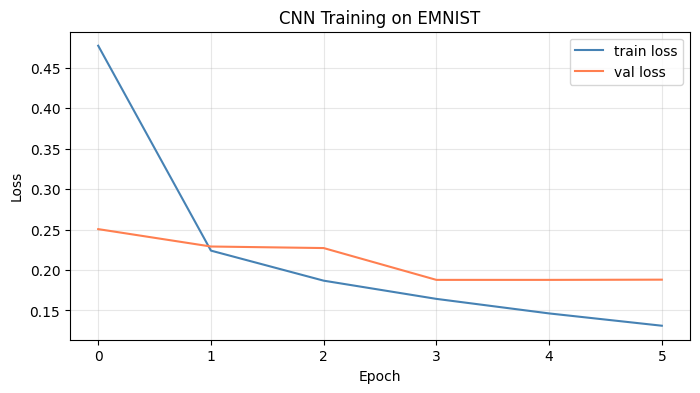

In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses   = []

for epoch in range(6): 
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move to GPU
        y_batch = y_batch - 1
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_batch = y_batch - 1
            pred = model(X_batch)
            batch_val.append(criterion(pred, y_batch).item())
    val_losses.append(np.mean(batch_val))

    print(f'Epoch {epoch+1}: train loss={train_losses[-1]:.4f}  val loss={val_losses[-1]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'steelblue', label='train loss')
plt.plot(val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training on EMNIST')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
model.eval()
correct = 0
total   = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_batch = y_batch - 1
        logits = model(X_batch)
        preds  = torch.argmax(logits, dim=1)   # class with highest score
        correct += (preds == y_batch).sum().item()
        total   += y_batch.size(0)

print(f'Test accuracy: {correct/total:.4f} ({correct}/{total})')

Test accuracy: 0.9379 (19509/20800)


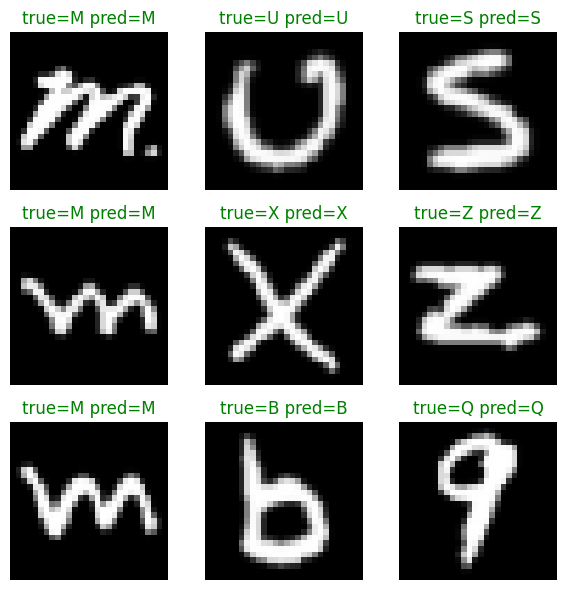

In [ ]:
alphabets = [
    'A', 'B', 'C', 'D', 'E', 'F', 
    'G', 'H', 'I', 'J', 'K', 'L', 
    'M', 'N', 'O', 'P', 'Q', 'R', 
    'S', 'T', 'U', 'V', 'W', 'X', 
    'Y', 'Z'
]

test_loader = DataLoader(test_data, batch_size=64, shuffle=True)
X_batch, y_batch = next(iter(test_loader))   # get one batch of 64 images
X_batch, y_batch = X_batch.to(device), y_batch.to(device)
y_batch = y_batch - 1

# run model on the batch
model.eval()
with torch.no_grad():
    logits = model(X_batch)
    preds = torch.argmax(logits, dim=1)

# plot first 9
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_batch[i, 0].cpu().T, cmap='gray')
    true  = alphabets[y_batch[i].item()]
    pred  = alphabets[preds[i].item()]
    color = 'green' if true == pred else 'red'
    ax.set_title(f'true={true} pred={pred}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

# accuracy and loss were worse compared to MNIST and it might be because increased number of classification